# Detecting steps and testing linearity

A GNSS or InSAR velocity is only worth quoting, and above all extrapolating, if a
single rate really describes the series. Two things routinely break that
assumption:

- **steps**: instantaneous offsets from earthquakes or equipment changes;
- **non-linear motion**: a rate that changes or accelerates (groundwater
  pumping, post-seismic relaxation, compaction).

This tutorial walks through the two tools that deal with them, on synthetic
series with known truth and then on a real station:

1. **`geepers.steps.detect_steps`** finds offsets that no catalog lists;
2. **`geepers.linearity.linearity_test`** decides between a linear, a quadratic
   and a piecewise-linear model under temporally correlated noise;
3. **`geepers.linearity.validity_horizon`** turns the verdict into the time over
   which the rate can be trusted.

Everything is in millimeters and millimeters per year.

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from geepers.linearity import linearity_test, validity_horizon
from geepers.steps import clean_step_dates, detect_steps, white_noise_sigma
from geepers.synthetic import power_law_noise

plt.rcParams["figure.dpi"] = 110

## 1. A synthetic station

Ten years of daily positions: a steady rate, an annual cycle, white noise and
flicker noise (the temporally correlated noise every GNSS series carries), plus
one 20 mm offset in 2016.

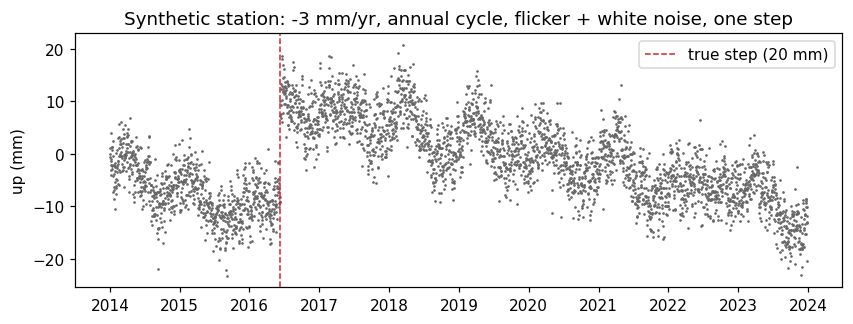

In [2]:
n = 3650
dates = pd.date_range("2014-01-01", periods=n, freq="D")
t = np.arange(n) / 365.25
rng = np.random.default_rng(7)

noise = rng.normal(0, 2.0, n) + 1.5 * power_law_noise(n, spectral_index=-1, seed=7)
steady = -3.0 * t + 3.0 * np.sin(2 * np.pi * t) + noise

STEP_DATE = pd.Timestamp("2016-06-10")
with_step = pd.Series(steady + 20.0 * (dates >= STEP_DATE), index=dates)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(with_step, ".", ms=1.5, color="0.4")
ax.axvline(STEP_DATE, color="C3", ls="--", lw=1, label="true step (20 mm)")
ax.set(ylabel="up (mm)", title="Synthetic station: -3 mm/yr, annual cycle, flicker + white noise, one step")
ax.legend();

## 2. Detecting steps

`detect_steps` slides a window along the series and, at every epoch, compares a
straight line with a line plus a step (AIC). On its own that test assumes white
noise. Flicker noise wanders, and a wandering series is always fitted a little
better with a step in it, so the AIC test alone reports false steps, more of
them the longer the window.

A detection must therefore also be larger than `min_step_sigma` (default 3)
times the day-to-day noise level of the series, which `white_noise_sigma`
estimates robustly from the differences between consecutive samples (here the
2 mm of white noise plus the short-period part of the flicker noise).

In [3]:
print(f"day-to-day noise level: {white_noise_sigma(with_step.to_numpy()):.1f} mm\n")

for window in (60, 300):
    aic_only = detect_steps(with_step, window_days=window, min_step_sigma=0)
    default = detect_steps(with_step, window_days=window)
    print(f"window {window:3d} d   AIC only: {len(aic_only):2d} detections   with the size check: {len(default)}")

found = detect_steps(with_step)
found

day-to-day noise level: 3.1 mm



window  60 d   AIC only:  5 detections   with the size check: 1


window 300 d   AIC only: 26 detections   with the size check: 4


,date,step_size,delta_aic
0,2016-06-10,18.575614,64.526144


At the default 60-day window only the real step survives, at the right date and
close to its true size. A 300-day window still lets a few false ones through
even with the size check, so keep the window short. Steps smaller than about
three times the noise cannot be told apart from flicker noise by any rule; that
is a limit of the data.

For real stations, combine the detections with the catalogued ones from
`UnrSource().steps(station_ids=[...])` (equipment changes and nearby
earthquakes) before fitting anything.

## 3. Is one rate enough?

`linearity_test` fits three models and prefers the one with the lowest BIC:

| model | meaning |
|---|---|
| `linear` | one rate describes the series |
| `quadratic` | the rate changes steadily (an acceleration) |
| `piecewise` | the rate changes at a breakpoint, which is searched for |

All three are compared under the *same* noise covariance, so that no model
wins just by leaving less for the noise to explain.

The test factorizes a dense covariance matrix, which is slow for thousands of
daily samples, and the question it asks is about the low frequencies anyway. So
average the series first; 30-day means are a good default.

In [4]:
def monthly(series):
    # 30-day means, on a regular grid the test can index
    return series.resample("30D").mean().dropna()


def summarize(name, result, tolerance=10.0):
    horizon = validity_horizon(result, tolerance=tolerance)
    print(
        f"{name:28s} {result.model:9s}  rate {result.trend.velocity:+6.2f} ± {result.trend.velocity_uncertainty:4.2f} mm/yr"
        f"   off the line {result.departure:5.1f} mm   within {tolerance:.0f} mm for {horizon.years:5.1f} yr ({horizon.driver})"
    )


steady_m = monthly(pd.Series(steady, index=dates))
result_steady = linearity_test(steady_m.index, steady_m.to_numpy(), sampling_days=30)
summarize("steady", result_steady)
result_steady.p_values

steady                       linear     rate  -2.76 ± 0.24 mm/yr   off the line   0.0 mm   within 10 mm for  41.8 yr (rate uncertainty)


{'quadratic': 0.7675746032906907, 'piecewise': 0.8260869565217391}

The steady series is called linear, and neither alternative is significant.

### An undeclared step looks like non-linearity

The test has no offset term unless you give it one. Run it on the series with
the step, first as is, then with the step date found in section 2.

In [5]:
step_m = monthly(with_step)

undeclared = linearity_test(step_m.index, step_m.to_numpy(), sampling_days=30)
declared = linearity_test(
    step_m.index, step_m.to_numpy(), sampling_days=30, step_dates=found["date"].tolist()
)
summarize("step, not declared", undeclared)
summarize("step, declared", declared)
print(f"\nestimated offset: {declared.trend.parameters['step_0'][0]:.1f} ± {declared.trend.parameters['step_0'][1]:.1f} mm (truth 20)")

step, not declared           piecewise  rate  -0.48 ± 0.42 mm/yr   off the line  10.9 mm   within 10 mm for   1.4 yr (non-linearity)
step, declared               linear     rate  -2.77 ± 0.31 mm/yr   off the line   0.0 mm   within 10 mm for  32.4 yr (rate uncertainty)

estimated offset: 20.0 ± 1.4 mm (truth 20)


Undeclared, the offset is reported as non-linear motion and the fitted rate is
badly biased. Declared, the series is linear again and the rate is back near
-3 mm/yr.

The test is not a step detector, though. Put the same kind of offset in the
middle of the record and it goes unnoticed: a mid-record offset tilts the
whole series, which a straight line absorbs.

In [6]:
mid_step = monthly(pd.Series(steady + 12.0 * (dates >= pd.Timestamp("2019-03-10")), index=dates))
summarize("mid-record step, undeclared", linearity_test(mid_step.index, mid_step.to_numpy(), sampling_days=30))
summarize("same series, no step at all", result_steady)

mid-record step, undeclared  linear     rate  -1.29 ± 0.32 mm/yr   off the line   0.0 mm   within 10 mm for  31.7 yr (rate uncertainty)
same series, no step at all  linear     rate  -2.76 ± 0.24 mm/yr   off the line   0.0 mm   within 10 mm for  41.8 yr (rate uncertainty)


Still "linear", with a confident uncertainty, and a rate that is wrong by
several of its own sigmas. **Detect or look up the steps first, then test
linearity.**

### Real non-linearity

Two series whose rate genuinely changes: one doubles its subsidence rate in
2019, the other accelerates steadily.

In [7]:
rate_change = pd.Series(steady - 3.0 * np.maximum(0, t - 5.2), index=dates)
accelerating = pd.Series(steady - 0.3 * (t - t.mean()) ** 2, index=dates)

results = {"steady": result_steady}
for name, series in (("rate doubles in 2019", rate_change), ("accelerating", accelerating)):
    m = monthly(series)
    results[name] = linearity_test(m.index, m.to_numpy(), sampling_days=30)
    summarize(name, results[name])

r = results["rate doubles in 2019"]
print(f"\nrate change:  {r.rate_before:+.2f} -> {r.rate_after:+.2f} mm/yr at {r.breakpoint.date()}  (p = {r.p_values['piecewise']:.4f})")
r = results["accelerating"]
print(f"acceleration: {r.acceleration:+.2f} ± {r.acceleration_sigma:.2f} mm/yr²  (p = {r.p_values['quadratic']:.4f}; truth -0.60)")

rate doubles in 2019         quadratic  rate  -4.10 ± 0.26 mm/yr   off the line   4.4 mm   within 10 mm for   5.6 yr (non-linearity)


accelerating                 quadratic  rate  -2.65 ± 0.26 mm/yr   off the line   5.2 mm   within 10 mm for   5.2 yr (non-linearity)

rate change:  -2.62 -> -5.96 mm/yr at 2019-03-08  (p = 0.0005)
acceleration: -0.64 ± 0.15 mm/yr²  (p = 0.0000; truth -0.60)


Both are rejected as linear. Three things to read off the result:

- **`departure`** is how far the preferred model strays from the straight line
  within the record, in mm: the cost of pretending the series is linear.
- **`p_values`** test each alternative against the linear model. The piecewise
  one allows for the breakpoint having been searched for, which an ordinary
  chi-square p-value would not.
- A rate change near the middle of the record is often reported as
  `quadratic`: the two shapes are close and the breakpoint costs one more
  parameter. Either verdict says the same thing about extrapolation, and
  `breakpoint`, `rate_before` and `rate_after` are filled in regardless.

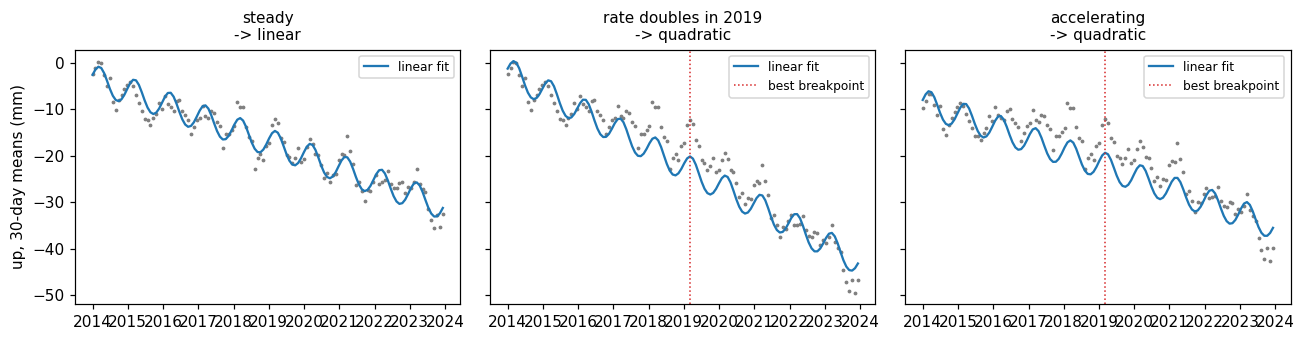

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, (name, series) in zip(axes, (("steady", pd.Series(steady, index=dates)), ("rate doubles in 2019", rate_change), ("accelerating", accelerating))):
    m, res = monthly(series), results[name]
    ax.plot(m, ".", ms=3, color="0.5")
    ax.plot(m.index, res.trend.model, color="C0", lw=1.5, label="linear fit")
    if res.breakpoint is not None and res.model != "linear":
        ax.axvline(res.breakpoint, color="C3", ls=":", lw=1, label="best breakpoint")
    ax.set_title(f"{name}\n-> {res.model}", fontsize=10)
    ax.legend(fontsize=8)
axes[0].set_ylabel("up, 30-day means (mm)")
fig.tight_layout()

## 4. How far can the rate be carried?

`validity_horizon` answers the question a rate alone cannot: after how many
years is the extrapolation expected to be off by more than a tolerance? The
error grows with the rate uncertainty, and with whatever non-linearity the
test found.

In [9]:
rows = []
for name, res in results.items():
    for tol in (5.0, 10.0, 50.0):
        h = validity_horizon(res, tolerance=tol)
        rows.append({"series": name, "model": res.model, "tolerance (mm)": tol, "horizon (yr)": round(h.years, 1), "set by": h.driver})
pd.DataFrame(rows).pivot(index=["series", "model"], columns="tolerance (mm)", values="horizon (yr)")

,tolerance (mm),5.0,10.0,50.0
series,model,,,
accelerating,quadratic,3.6,5.2,12.1
rate doubles in 2019,quadratic,3.8,5.6,13.1
steady,linear,20.9,41.8,209.2


The steady rate holds to 10 mm for decades; the two non-linear series for a few
years at most. A site in the second group should not enter a long-term
projection as a single rate.

## 5. The noise model matters

Curvature and strongly correlated noise look alike over a single record, so the
verdict depends on what the noise is allowed to be.

- The default, **flicker + white** (`"FNWN"`), is the usual model of GNSS
  noise.
- Letting the spectral index go free (`"PLWN"`) sounds safer and is not: the
  index runs to its steep limit and explains an offset or a rate change as
  noise. The series is then called linear, with a rate uncertainty so large
  that it says nothing.

In [10]:
for noise_model in ("FNWN", "PLWN"):
    res = linearity_test(step_m.index, step_m.to_numpy(), sampling_days=30, noise_model=noise_model)
    print(f"{noise_model}:  {res.model:9s}  rate {res.trend.velocity:+.2f} ± {res.trend.velocity_uncertainty:.2f} mm/yr   spectral index {res.trend.kappa:.2f}")

FNWN:  piecewise  rate -0.48 ± 0.42 mm/yr   spectral index -1.00


PLWN:  linear     rate -0.89 ± 2.53 mm/yr   spectral index -1.97


The price of the fixed index: a linear series whose noise really is a random
walk is flagged about one time in five. Treat a non-linear verdict as a reason
to look at the series, not as proof.

## 6. A real station

P595 sits close to the July 2019 Ridgecrest earthquakes (California), which
moved it by about 0.6 m to the east. This section downloads its daily positions
and its step catalog from the Nevada Geodetic Laboratory, so it needs an
internet connection.

catalogued: ['2018-02-11 (Elevation_Cutoff_Changed)', '2019-07-04 (ci38443183)', '2019-07-06 (ci38457511)', '2019-07-06 (ci38457687)', '2020-05-15 (nn00725272)', '2020-06-04 (ci39462536)', '2020-06-24 (ci39493944)', '2025-03-19 (Antenna_Type_Changed)', '2025-03-19 (Receiver_Make_and_Model_Changed)']
detected:   ['2018-10-14 (+3 mm)', '2019-07-06 (+612 mm)', '2026-01-22 (+3 mm)', '2026-04-22 (-3 mm)']


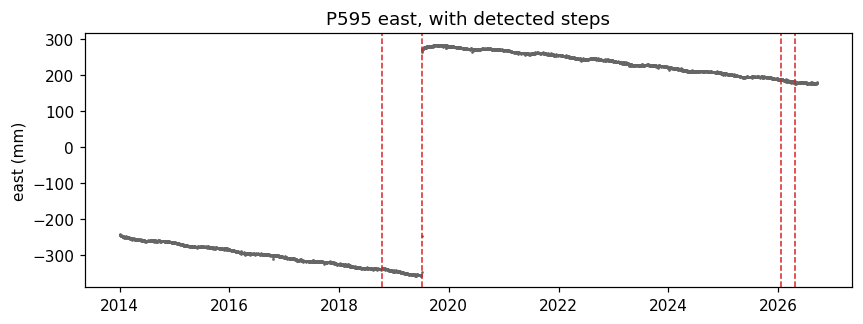

In [11]:
from geepers.gps_sources import UnrSource

source = UnrSource()
df = source.timeseries("P595", start_date="2014-01-01")
east = pd.Series(df["east"].to_numpy() * 1000, index=pd.DatetimeIndex(df["date"]))  # m -> mm

catalog = source.steps(station_ids=["P595"])
catalog = catalog[catalog["date"] >= "2014-01-01"]
detected = detect_steps(east)

print("catalogued:", [f"{d.date()} ({desc})" for d, desc in zip(catalog["date"], catalog["description"])])
print("detected:  ", [f"{d.date()} ({s:+.0f} mm)" for d, s in zip(detected["date"], detected["step_size"])])

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(east, ".", ms=1.5, color="0.4")
for d in detected["date"]:
    ax.axvline(d, color="C3", ls="--", lw=1)
ax.set(ylabel="east (mm)", title="P595 east, with detected steps");

In [12]:
east_m = monthly(east)

# Detected and catalogued steps together. Passed as they come they make the fit
# singular: two entries within one 30-day sample are the same offset to it.
steps = clean_step_dates(
    detected["date"].tolist() + catalog["date"].tolist(),
    start=east_m.index[0], end=east_m.index[-1], min_separation_days=30,
)
print("steps used:", [str(d.date()) for d in steps], "\n")

as_is = linearity_test(east_m.index, east_m.to_numpy(), sampling_days=30)
with_steps = linearity_test(east_m.index, east_m.to_numpy(), sampling_days=30, step_dates=steps)
summarize("P595 east, no steps", as_is)
summarize("P595 east, with steps", with_steps)

steps used: ['2018-02-11', '2018-10-14', '2019-07-04', '2020-05-15', '2020-06-24', '2025-03-19', '2026-01-22', '2026-04-22'] 



P595 east, no steps          linear     rate +45.24 ± 7.23 mm/yr   off the line   0.0 mm   within 10 mm for   1.4 yr (rate uncertainty)
P595 east, with steps        linear     rate -15.83 ± 0.81 mm/yr   off the line   0.0 mm   within 10 mm for  12.4 yr (rate uncertainty)


The detector finds the earthquake offset on its own, plus a few 3 mm steps right
at its size limit; the catalog adds the equipment changes and the smaller
earthquakes. `clean_step_dates` merges the two lists into one the fit can use.

This is the mid-record case of section 3 on real data. With no steps declared
the test says "linear" and returns +45 mm/yr: the offset, which falls near the
middle of the record, has been turned into a rate with the wrong sign. The only
symptom is the large rate uncertainty. With the steps declared the rate is
about -16 mm/yr with an uncertainty nine times smaller, and one rate describes
what is left.

Eight offsets are a lot of freedom, though. Each one costs precision, and
offsets a few months apart can soak up slow post-seismic motion that is not a
step at all. Where that matters, model the relaxation instead with
`geepers.trend.estimate_trend(postseismic_log=...)`.

## Summary

1. Find the steps: `detect_steps` for the uncatalogued ones, `UnrSource.steps`
   for the catalogued ones, `clean_step_dates` to merge them.
2. Average to about 30 days and run `linearity_test` with those `step_dates`.
3. Read `model`, `departure` and `p_values`; use `validity_horizon` to decide
   how far the rate may be carried.
4. Keep the noise model at flicker + white unless you have a reason not to.

The [web viewer](https://opera-adt.github.io/geepers/) runs the same test in the
browser (the **Linearity** checkbox and the chart's `linearity` button), with
the offsets its step detector finds.